Building likelihood maps for a set of representative images.

> TODO: use images from dataset and superimpose the bounding boxes on them

In [1]:
from retinotopy import *


HOST='Ahsoka'
On date 2024-04-25, Running learning on host Ahsoka with device cpu
Welcome on macOS-14.4.1-x86_64-i386-64bit


In [2]:
args = Params()
data_set_type = 'full'
args.root  = f'{DATAROOT}/Imagenet_{data_set_type}' # Directory containing images
args.folders = ['val'] # type of images to use
    

In [3]:
# %ls {args.root}/{args.folders[0]}

In [4]:

image_dataset = torchvision.datasets.ImageFolder(os.path.join(args.root, args.folders[0]), transform=T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)]))
dataloader = torch.utils.data.DataLoader(image_dataset, batch_size=1, shuffle=True, num_workers=1)
len(image_dataset)

50001

In [5]:
for full_image, label in dataloader:
    break
full_image.shape, label

(torch.Size([1, 3, 375, 500]), tensor([424]))

In [6]:
dataloader.dataset.classes[label[0]]


'n02791270'

In [7]:

dataloader.dataset.samples[0]

('/Volumes/data/2024_archives/2024_science/Deep_learning/data/Imagenet_full/val/n01440764/ILSVRC2012_val_00000293.JPEG',
 0)

In [8]:
for i in range(10): print(dataloader.dataset.imgs[i][0])

/Volumes/data/2024_archives/2024_science/Deep_learning/data/Imagenet_full/val/n01440764/ILSVRC2012_val_00000293.JPEG
/Volumes/data/2024_archives/2024_science/Deep_learning/data/Imagenet_full/val/n01440764/ILSVRC2012_val_00002138.JPEG
/Volumes/data/2024_archives/2024_science/Deep_learning/data/Imagenet_full/val/n01440764/ILSVRC2012_val_00003014.JPEG
/Volumes/data/2024_archives/2024_science/Deep_learning/data/Imagenet_full/val/n01440764/ILSVRC2012_val_00006697.JPEG
/Volumes/data/2024_archives/2024_science/Deep_learning/data/Imagenet_full/val/n01440764/ILSVRC2012_val_00007197.JPEG
/Volumes/data/2024_archives/2024_science/Deep_learning/data/Imagenet_full/val/n01440764/ILSVRC2012_val_00009111.JPEG
/Volumes/data/2024_archives/2024_science/Deep_learning/data/Imagenet_full/val/n01440764/ILSVRC2012_val_00009191.JPEG
/Volumes/data/2024_archives/2024_science/Deep_learning/data/Imagenet_full/val/n01440764/ILSVRC2012_val_00009346.JPEG
/Volumes/data/2024_archives/2024_science/Deep_learning/data/Imag

In [9]:
idx = 324
image_dataset[idx], image_dataset.samples[idx]

((Image([[[0.125, 0.153, 0.153,  ..., 0.157, 0.161, 0.173],
          [0.153, 0.153, 0.157,  ..., 0.165, 0.173, 0.176],
          [0.161, 0.157, 0.165,  ..., 0.184, 0.184, 0.188],
          ...,
          [0.176, 0.176, 0.176,  ..., 0.514, 0.518, 0.525],
          [0.184, 0.176, 0.165,  ..., 0.518, 0.525, 0.529],
          [0.169, 0.153, 0.133,  ..., 0.522, 0.525, 0.533]],
  
         [[0.553, 0.569, 0.561,  ..., 0.604, 0.608, 0.612],
          [0.561, 0.557, 0.561,  ..., 0.596, 0.596, 0.600],
          [0.565, 0.549, 0.557,  ..., 0.608, 0.608, 0.612],
          ...,
          [0.231, 0.231, 0.239,  ..., 0.694, 0.698, 0.706],
          [0.231, 0.239, 0.235,  ..., 0.698, 0.706, 0.710],
          [0.216, 0.216, 0.212,  ..., 0.702, 0.706, 0.714]],
  
         [[0.541, 0.561, 0.557,  ..., 0.604, 0.608, 0.616],
          [0.557, 0.553, 0.557,  ..., 0.600, 0.604, 0.608],
          [0.561, 0.549, 0.549,  ..., 0.616, 0.616, 0.620],
          ...,
          [0.231, 0.231, 0.239,  ..., 0.643, 0.

In [10]:
image_dataset[idx], os.path.basename(image_dataset.samples[idx][0].split('.')[0])

((Image([[[0.125, 0.153, 0.153,  ..., 0.157, 0.161, 0.173],
          [0.153, 0.153, 0.157,  ..., 0.165, 0.173, 0.176],
          [0.161, 0.157, 0.165,  ..., 0.184, 0.184, 0.188],
          ...,
          [0.176, 0.176, 0.176,  ..., 0.514, 0.518, 0.525],
          [0.184, 0.176, 0.165,  ..., 0.518, 0.525, 0.529],
          [0.169, 0.153, 0.133,  ..., 0.522, 0.525, 0.533]],
  
         [[0.553, 0.569, 0.561,  ..., 0.604, 0.608, 0.612],
          [0.561, 0.557, 0.561,  ..., 0.596, 0.596, 0.600],
          [0.565, 0.549, 0.557,  ..., 0.608, 0.608, 0.612],
          ...,
          [0.231, 0.231, 0.239,  ..., 0.694, 0.698, 0.706],
          [0.231, 0.239, 0.235,  ..., 0.698, 0.706, 0.710],
          [0.216, 0.216, 0.212,  ..., 0.702, 0.706, 0.714]],
  
         [[0.541, 0.561, 0.557,  ..., 0.604, 0.608, 0.616],
          [0.557, 0.553, 0.557,  ..., 0.600, 0.604, 0.608],
          [0.561, 0.549, 0.549,  ..., 0.616, 0.616, 0.620],
          ...,
          [0.231, 0.231, 0.239,  ..., 0.643, 0.

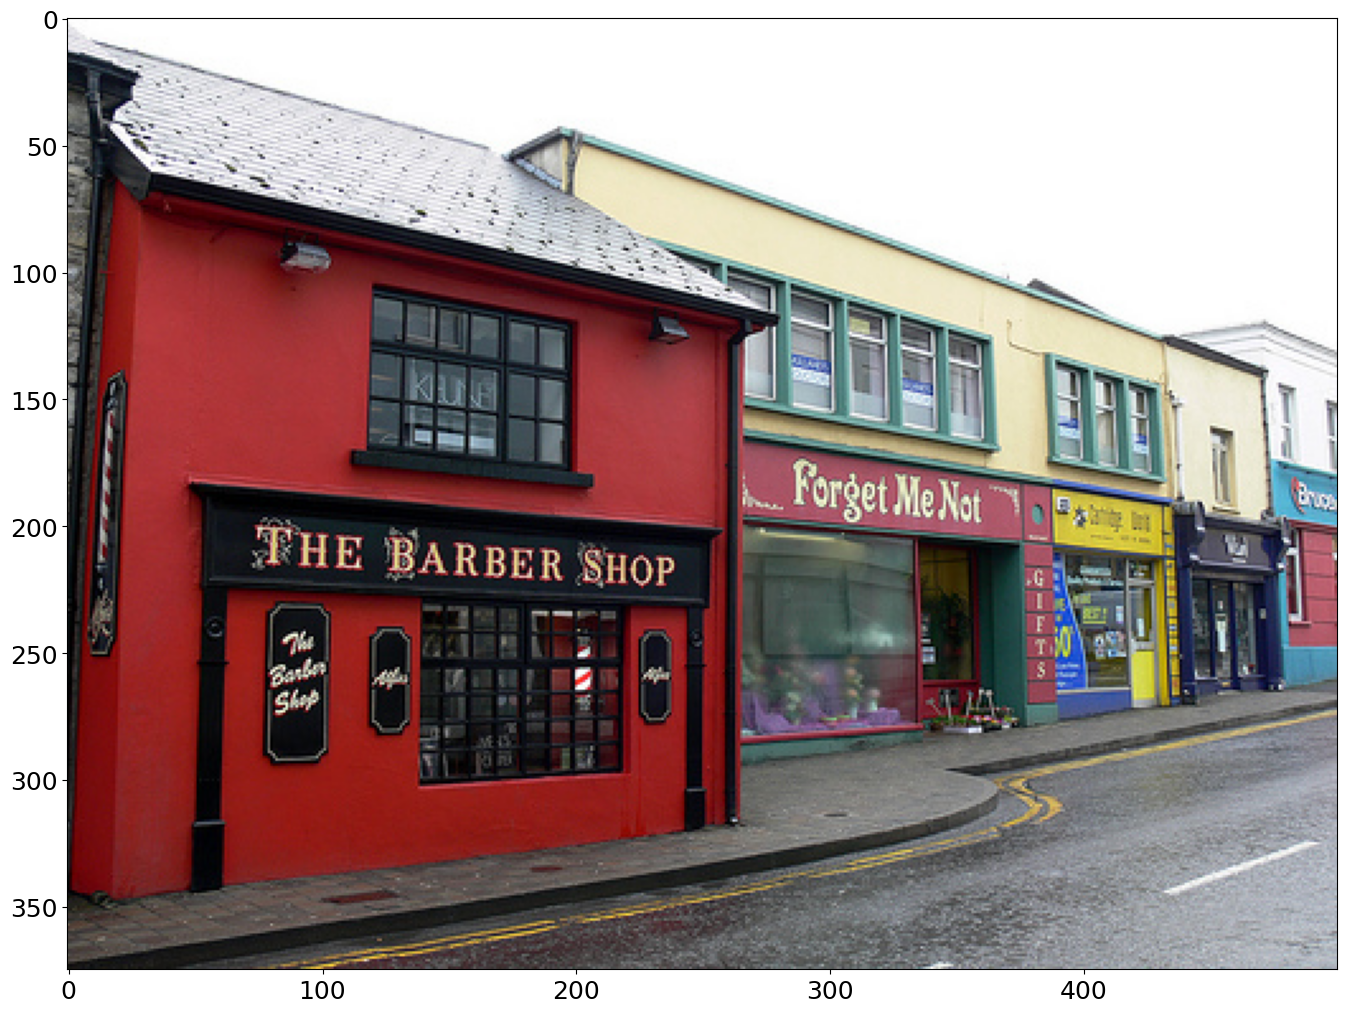

In [11]:
fig, ax = plt.subplots(figsize=(fig_width, fig_width/phi))
ax.imshow(torch.movedim(full_image.squeeze(0), (1, 2, 0), (0, 1, 2)).numpy())


## doing the computations

In [12]:
resolution = (128, 128)
resolution = (32, 32)
resolution = (64, 64)
size_ratio = 0.3 # how much of the image to use relative to radius
N_image = 100

In [13]:
for model_data_set_type in ['focus']: # data_set_types:
    print(50*'=')
    print(f'{model_data_set_type=}')    

    # The dataset to import images from
    data_set_type = 'full'
    args = Params()
    args.root  = f'{DATAROOT}/Imagenet_{data_set_type}' # Directory containing images
    args.folders = ['val'] # type of images to use
    image_dataset = torchvision.datasets.ImageFolder(os.path.join(args.root, args.folders[0]), transform=T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)]))
    # dataloader = torch.utils.data.DataLoader(image_dataset, batch_size=1, shuffle=True, num_workers=1)
    idxs = np.random.permutation(len(image_dataset))[:N_image]
    print(50*'-')

    for model_name in ['resnet101', 'resnet50', 'resnet18']: #  ['resnet18']: #
        print(f'{model_name=}')    
        print(50*'.')

        for do_polar in [True, False]:
            args.do_polar = do_polar
            print(f'{args.do_polar=}')
            print(50*'.')
            df_filename = f'{data_cache}/{datetag}_{model_data_set_type}_{model_name}_{do_polar=}_results_likelihood-maps.parquet'
            if os.path.isfile(df_filename):
                df_map = pd.read_parquet(df_filename)
            else:
                model_filename = f'{data_cache}/{datetag}_{model_data_set_type}_{model_name}_{do_polar=}.pt'
                df_map = None
                if os.path.isfile(model_filename):
                    model = charge_model(model_name=model_name, model_path=model_filename, do_circular=args.do_polar).to(device).eval()

                    for i_image, idx in tqdm(enumerate(idxs)):
                        full_image, label = image_dataset[idx]
                        ImageId = os.path.basename(image_dataset.samples[idx][0].split('.')[0])

                        full_image = full_image.to(device)
                        full_image = full_image.squeeze(0)

                        N_fixations = np.prod(resolution)
                        aspect_ratio = full_image.shape[1]/full_image.shape[2]
                        resolution_ = (int(np.sqrt(N_fixations*aspect_ratio)),
                                       int(np.sqrt(N_fixations/aspect_ratio)))

                        pos_H, pos_W, box_size = get_positions(full_image, resolution, size_ratio)
                        args.image_size = box_size
                        args.do_polar = do_polar

                        pos_H, pos_W, outputs = compute_likelihood_map(args, model, full_image, resolution=resolution)
                        proba_label = outputs[:, label]

                        df_map_ = pd.DataFrame({'ImageId':ImageId, 'label':label, 'pos_H':pos_H.astype(int).ravel(), 'pos_W':pos_W.astype(int).ravel(), 'proba_label':proba_label})
                        if df_map is None:
                            df_map = df_map_
                        else:
                            df_map = pd.concat([df_map, df_map_], ignore_index=True)

                    df_map.to_parquet(df_filename)                        
                    print(25*'. ')
                else:
                    print(f' 😵‍💫 {model_filename} not found')
                    print(50*'-')
                    

data_set_type='full'
--------------------------------------------------
model_name='resnet101'
..................................................
args.do_polar=True
..................................................
loading .... cached_data/2024-04-25_focus_resnet101_do_polar=True.pt


100it [2:41:25, 96.85s/it] 


. . . . . . . . . . . . . . . . . . . . . . . . . 
args.do_polar=False
..................................................
loading .... cached_data/2024-04-25_focus_resnet101_do_polar=False.pt


49it [54:58, 65.93s/it] 

In [ ]:
df_map

In [ ]:
for data_set_type in ['full']: # data_set_types:
    print(50*'=')
    print(f'{data_set_type=}')    

    args = Params()
    args.root  = f'{DATAROOT}/Imagenet_{data_set_type}' # Directory containing images
    args.folders = ['val'] # type of images to use
    print(50*'-')

    image_dataset = torchvision.datasets.ImageFolder(os.path.join(args.root, args.folders[0]), transform=T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)]))
    # dataloader = torch.utils.data.DataLoader(image_dataset, batch_size=1, shuffle=True, num_workers=1)
    idxs = np.random.permutation(len(image_dataset))[:N_image]

    for model_name in ['resnet101']:#, 'resnet50', 'resnet18']:
        print(f'{model_name=}')    
        print(50*'.')

        for do_polar in [False, True]:
            args.do_polar = do_polar
            print(f'{args.do_polar=}')
            print(50*'.')
            df_filename = f'{data_cache}/{datetag}_{data_set_type}_{model_name}_{do_polar=}_results_likelihood-maps.parquet'
            if os.path.isfile(df_filename):
                df_map = pd.read_parquet(df_filename)


In [ ]:
ImageIds = df_map['ImageId'].unique()
for ImageId in ImageIds:
    df_map_ = df_map[df_map['ImageId']==ImageId]
    fig, ax = plt.subplots(figsize=(fig_width, fig_width/phi))
    # ax.imshow(torch.movedim(full_image.squeeze(0), (1, 2, 0), (0, 1, 2)).numpy())
    ax.scatter(df_map_['pos_H'], df_map_['pos_W'], s=df_map_['proba_label']*100)
    ax.axis('off')
    ax.set_title(f'{ImageId} {model_name} {do_polar=}')
    plt.show()
    break

In [ ]:
df_map_['proba_label'].max(), df_map_['proba_label'].argmax()

In [ ]:
ImageIds = df_map['ImageId'].unique()
results = np.zeros((0, 2))
for ImageId in ImageIds:
    df_map_ = df_map[df_map['ImageId']==ImageId].reset_index(drop=True)
    pos_hotest = df_map_['proba_label'].argmax()
    distances_ = np.sqrt((df_map_['pos_H']-df_map_['pos_H'][pos_hotest])**2 + (df_map_['pos_W']-df_map_['pos_W'][pos_hotest])**2)
    distances_ /= distances_.max()
    results = np.vstack([results, np.vstack([distances_, df_map_['proba_label']]).T])
    
results.shape

In [ ]:
def logit(p):
    return np.log(p/(1-p))

In [ ]:
fig, ax = plt.subplots(figsize=(fig_width, fig_width/phi))
# ax.imshow(torch.movedim(full_image.squeeze(0), (1, 2, 0), (0, 1, 2)).numpy())
ax.scatter(results[:, 0], logit(results[:, 1]), alpha=.01)
plt.show()


In [ ]:

for data_set_type in ['full']: # data_set_types:
    print(50*'=')
    print(f'{data_set_type=}')    

    fig, ax = plt.subplots(figsize=(fig_width, fig_width/phi))
    # ax.imshow(torch.movedim(full_image.squeeze(0), (1, 2, 0), (0, 1, 2)).numpy())
    for model_name in ['resnet101']:#, 'resnet50', 'resnet18']:
        print(f'{model_name=}')    
        print(50*'.')

        for do_polar in [False, True]:
            args.do_polar = do_polar
            print(f'{args.do_polar=}')
            print(50*'.')
            df_filename = f'{data_cache}/{datetag}_{data_set_type}_{model_name}_{do_polar=}_results_likelihood-maps.parquet'
            if os.path.isfile(df_filename):
                df_map = pd.read_parquet(df_filename)

                ImageIds = df_map['ImageId'].unique()
                results = np.zeros((0, 2))
                for ImageId in ImageIds:
                    df_map_ = df_map[df_map['ImageId']==ImageId].reset_index(drop=True)
                    pos_hotest = df_map_['proba_label'].argmax()
                    distances_ = np.sqrt((df_map_['pos_H']-df_map_['pos_H'][pos_hotest])**2 + (df_map_['pos_W']-df_map_['pos_W'][pos_hotest])**2)
                    distances_ /= distances_.max()
                    results = np.vstack([results, np.vstack([distances_, df_map_['proba_label']]).T])
                
                ax.scatter(results[:, 0], logit(results[:, 1])-logit(1/1000), alpha=.03, c='r' if do_polar else 'b')
                ax.hlines(0, 0, 1, color='k', linestyle='--')
        plt.show()


In [ ]:
# from scipy.interpolate import UnivariateSpline

# for data_set_type in ['full']: # data_set_types:
#     print(50*'=')
#     print(f'{data_set_type=}')    

#     fig, ax = plt.subplots(figsize=(fig_width, fig_width/phi))
#     # ax.imshow(torch.movedim(full_image.squeeze(0), (1, 2, 0), (0, 1, 2)).numpy())
#     for model_name in ['resnet101', 'resnet50', 'resnet18']:
#         print(f'{model_name=}')    
#         print(50*'.')

#         for do_polar in [False, True]:
#             args.do_polar = do_polar
#             print(f'{args.do_polar=}')
#             print(50*'.')
#             df_filename = f'{data_cache}/{datetag}_{data_set_type}_{model_name}_{do_polar=}_results_likelihood-maps.parquet'
#             if os.path.isfile(df_filename):
#                 df_map = pd.read_parquet(df_filename)

#                 ImageIds = df_map['ImageId'].unique()
#                 results = np.zeros((0, 2))
#                 for ImageId in ImageIds:
#                     df_map_ = df_map[df_map['ImageId']==ImageId].reset_index(drop=True)
#                     pos_hotest = df_map_['proba_label'].argmax()
#                     distances_ = np.sqrt((df_map_['pos_H']-df_map_['pos_H'][pos_hotest])**2 + (df_map_['pos_W']-df_map_['pos_W'][pos_hotest])**2)
#                     distances_ /= distances_.max()
#                     results = np.vstack([results, np.vstack([distances_, df_map_['proba_label']]).T])
                
#                 # ax.scatter(results[:, 0], logit(results[:, 1])-logit(1/1000), alpha=.03, c='r' if do_polar else 'b')

#                 x, y = results[:, 0], logit(results[:, 1])-logit(1/1000)
#                 idx_sort = np.argsort(x)
#                 x, y = x[idx_sort], y[idx_sort]
#                 # Calcul du lissage par spline
#                 spline = UnivariateSpline(x, y)
#                 xs = np.linspace(min(x), max(x), 1000)
#                 ys = spline(xs)
#                 ax.plot(xs, ys)

#                 ax.hlines(0, min(x), max(x), color='k', linestyle='--')
#         plt.show()


In [ ]:
N_bins = 25
for data_set_type in ['full']: # data_set_types:
    print(50*'=')
    print(f'{data_set_type=}')    

    fig, ax = plt.subplots(figsize=(fig_width, fig_width/phi))
    # ax.imshow(torch.movedim(full_image.squeeze(0), (1, 2, 0), (0, 1, 2)).numpy())
    for model_name in ['resnet101', 'resnet50', 'resnet18']:
        print(f'{model_name=}')    
        print(50*'.')

        for do_polar in [False, True]:
            args.do_polar = do_polar
            print(f'{args.do_polar=}')
            print(50*'.')
            df_filename = f'{data_cache}/{datetag}_{data_set_type}_{model_name}_{do_polar=}_results_likelihood-maps.parquet'
            if os.path.isfile(df_filename):
                df_map = pd.read_parquet(df_filename)

                ImageIds = df_map['ImageId'].unique()
                results = np.zeros((0, 2))
                for ImageId in ImageIds:
                    df_map_ = df_map[df_map['ImageId']==ImageId].reset_index(drop=True)
                    pos_hotest = df_map_['proba_label'].argmax()
                    distances_ = np.sqrt((df_map_['pos_H']-df_map_['pos_H'][pos_hotest])**2 + (df_map_['pos_W']-df_map_['pos_W'][pos_hotest])**2)
                    distances_ /= distances_.max()
                    results = np.vstack([results, np.vstack([distances_, df_map_['proba_label']]).T])
                
                # ax.scatter(results[:, 0], logit(results[:, 1])-logit(1/1000), alpha=.03, c='r' if do_polar else 'b')

                # x, y = results[:, 0], logit(results[:, 1])-logit(1/1000)
                x, y = results[:, 0], results[:, 1]
                xs = np.linspace(min(x), max(x), N_bins+1, endpoint=True)
                x_mean, y_mean, y_err = [], [], []
                for i_bin, (xbin_min, xbin_max) in enumerate(zip(xs[:-1], xs[1:])):
                    idx_bin = (x>=xbin_min) & (x<=xbin_max)
                    x_, y_ = x[idx_bin], y[idx_bin]
                    # x_mean.append((xbin_max+xbin_min)/2)
                    x_mean.append(x_.mean())
                    y_mean.append(y_.mean())
                    y_err.append(y_.std())
                shift = 0 if do_polar else .25/N_bins
                ax.errorbar([x+shift for x in x_mean], y_mean, yerr=y_err, fmt='.r' if do_polar else '.b')

                ax.hlines(0, min(x), max(x), color='k', linestyle='--')
        plt.show()


In [ ]:
# for data_set_type in ['full']: # data_set_types:
#     print(50*'=')
#     print(f'{data_set_type=}')    

#     fig, ax = plt.subplots(figsize=(fig_width, fig_width/phi))
#     # ax.imshow(torch.movedim(full_image.squeeze(0), (1, 2, 0), (0, 1, 2)).numpy())
#     for model_name in ['resnet101']:#, 'resnet50', 'resnet18']:
#         print(f'{model_name=}')    
#         print(50*'.')

#         for do_polar in [False, True]:
#             args.do_polar = do_polar
#             print(f'{args.do_polar=}')
#             print(50*'.')
#             df_filename = f'{data_cache}/{datetag}_{data_set_type}_{model_name}_{do_polar=}_results_likelihood-maps.parquet'
#             if os.path.isfile(df_filename):
#                 df_map = pd.read_parquet(df_filename)

#                 ImageIds = df_map['ImageId'].unique()
#                 results = np.zeros((0, 2))
#                 for ImageId in ImageIds:
#                     df_map_ = df_map[df_map['ImageId']==ImageId].reset_index(drop=True)
#                     pos_hotest = df_map_['proba_label'].argmax()
#                     distances_ = np.sqrt((df_map_['pos_H']-df_map_['pos_H'][pos_hotest])**2 + (df_map_['pos_W']-df_map_['pos_W'][pos_hotest])**2)
#                     # print(np.median(distances_))
#                     distances_ /= np.median(distances_)
#                     # print(np.median(distances_))
#                     results = np.vstack([results, np.vstack([distances_, df_map_['proba_label']]).T])
                
#                 ax.scatter(results[:, 0], logit(results[:, 1])-logit(1/1000), alpha=.03, c='r' if do_polar else 'b')
#                 ax.hlines(0, 0, 1, color='k', linestyle='--')
#         plt.show()


In [ ]:
for data_set_type in ['full']: # data_set_types:
    print(50*'=')
    print(f'{data_set_type=}')    

    fig, ax = plt.subplots(figsize=(fig_width, fig_width/phi))
    # ax.imshow(torch.movedim(full_image.squeeze(0), (1, 2, 0), (0, 1, 2)).numpy())
    for model_name in ['resnet101', 'resnet50', 'resnet18']:
        print(f'{model_name=}')    
        print(50*'.')

        for do_polar in [False, True]:
            args.do_polar = do_polar
            print(f'{args.do_polar=}')
            print(50*'.')
            df_filename = f'{data_cache}/{datetag}_{data_set_type}_{model_name}_{do_polar=}_results_likelihood-maps.parquet'
            if os.path.isfile(df_filename):
                df_map = pd.read_parquet(df_filename)

                ImageIds = df_map['ImageId'].unique()
                results = np.zeros((0, 2))
                for ImageId in ImageIds:
                    df_map_ = df_map[df_map['ImageId']==ImageId].reset_index(drop=True)
                    pos_hotest = df_map_['proba_label'].argmax()
                    distances_ = np.sqrt((df_map_['pos_H']-df_map_['pos_H'][pos_hotest])**2 + (df_map_['pos_W']-df_map_['pos_W'][pos_hotest])**2)
                    # print(np.median(distances_))
                    distances_ /= np.median(distances_)
                    # print(np.median(distances_))
                    results = np.vstack([results, np.vstack([distances_, df_map_['proba_label']]).T])
                
                # ax.scatter(results[:, 0], logit(results[:, 1])-logit(1/1000), alpha=.03, c='r' if do_polar else 'b')

                # x, y = results[:, 0], logit(results[:, 1])-logit(1/1000)
                x, y = results[:, 0], results[:, 1]
                xs = np.linspace(min(x), max(x), N_bins+1, endpoint=True)
                x_mean, y_mean, y_err = [], [], []
                for i_bin, (xbin_min, xbin_max) in enumerate(zip(xs[:-1], xs[1:])):
                    idx_bin = (x>=xbin_min) & (x<=xbin_max)
                    x_, y_ = x[idx_bin], y[idx_bin]
                    # x_mean.append((xbin_max+xbin_min)/2)
                    x_mean.append(x_.mean())
                    y_mean.append(y_.mean())
                    y_err.append(y_.std())
                shift = 0 if do_polar else .25/N_bins
                ax.errorbar([x+shift for x in x_mean], y_mean, yerr=y_err, fmt='.r' if do_polar else '.b')

                ax.hlines(0, min(x), max(x), color='k', linestyle='--')
        plt.show()


In [ ]:
plt.hist(results[:, 0], bins=100)

In [ ]:
for data_set_type in ['full']: # data_set_types:
    print(50*'=')
    print(f'{data_set_type=}')    

    fig, ax = plt.subplots(figsize=(fig_width, fig_width/phi))
    # ax.imshow(torch.movedim(full_image.squeeze(0), (1, 2, 0), (0, 1, 2)).numpy())
    for model_name in ['resnet101', 'resnet50', 'resnet18']:
        print(f'{model_name=}')    
        print(50*'.')

        for do_polar in [False, True]:
            args.do_polar = do_polar
            print(f'{args.do_polar=}')
            print(50*'.')
            df_filename = f'{data_cache}/{datetag}_{data_set_type}_{model_name}_{do_polar=}_results_likelihood-maps.parquet'
            if os.path.isfile(df_filename):
                df_map = pd.read_parquet(df_filename)

                ImageIds = df_map['ImageId'].unique()
                results = np.zeros((0, 2))
                for ImageId in ImageIds:
                    df_map_ = df_map[df_map['ImageId']==ImageId].reset_index(drop=True)
                    # center of gravity
                    pos_H_hotest = (df_map_['proba_label']*df_map_['pos_H']).sum()/df_map_['proba_label'].sum()
                    pos_W_hotest = (df_map_['proba_label']*df_map_['pos_W']).sum()/df_map_['proba_label'].sum()
                    distances_ = np.sqrt((df_map_['pos_H']-pos_H_hotest)**2 + (df_map_['pos_W']-pos_W_hotest)**2)
                    # print(np.median(distances_))
                    distances_ /= np.median(distances_)
                    # print(np.median(distances_))
                    results = np.vstack([results, np.vstack([distances_, df_map_['proba_label']]).T])
                
                # ax.scatter(results[:, 0], logit(results[:, 1])-logit(1/1000), alpha=.03, c='r' if do_polar else 'b')

                # x, y = results[:, 0], logit(results[:, 1])-logit(1/1000)
                x, y = results[:, 0], results[:, 1]
                xs = np.linspace(min(x), max(x), N_bins+1, endpoint=True)
                x_mean, y_mean, y_err = [], [], []
                for i_bin, (xbin_min, xbin_max) in enumerate(zip(xs[:-1], xs[1:])):
                    idx_bin = (x>=xbin_min) & (x<=xbin_max)
                    x_, y_ = x[idx_bin], y[idx_bin]
                    # x_mean.append((xbin_max+xbin_min)/2)
                    x_mean.append(x_.mean())
                    y_mean.append(y_.mean())
                    y_err.append(y_.std())
                shift = 0 if do_polar else .25/N_bins
                ax.errorbar([x+shift for x in x_mean], y_mean, yerr=y_err, fmt='.r' if do_polar else '.b')

                ax.hlines(0, min(x), max(x), color='k', linestyle='--')
        plt.show()


## reading localisation metadata

In [ ]:
with open(f'{args.root}/LOC_val_solution.csv', 'r') as csv_file:
    df_data = pd.read_csv(csv_file)

In [ ]:
df_data

In [ ]:
def get_boxes(df, value):
    idx = list(df['ImageId'][df['ImageId'] == value].index)
    bboxes = []
    if idx:
        for i in range(len(df["PredictionString"][idx[0]].split(' '))//5):
            pos =(5*i)
            bboxes.append({'xmin' : int(df["PredictionString"][idx[0]].split(' ')[1 + pos]),
                           'ymin' : int(df["PredictionString"][idx[0]].split(' ')[2 + pos]),
                           'xmax' : int(df["PredictionString"][idx[0]].split(' ')[3 + (5 *i)]),
                           'ymax' : int(df["PredictionString"][idx[0]].split(' ')[4 + (5 *i)])
                                        })
    return bboxes

In [ ]:
get_boxes(df_data, 'ILSVRC2012_val_00048981')

## doing the figure

In [ ]:
for data_set_type in data_set_types:
    print(50*'=')
    print(f'{data_set_type=}')    
    for model_name in  ['resnet18', 'resnet50', 'resnet101']:
        print(f'{model_name=}')    
        print(50*'.')

        fig, axs = plt.subplots(len(image_names), 3, figsize=(fig_width*len(image_names), fig_width))
        for i_image, (image_name, true_label) in enumerate(zip(image_names, true_labels)):

            image_url = f'./imgs/{image_name}.jpg'
            full_image = read_image(image_url)/255
            full_image_np = torch.movedim(full_image, (1, 2, 0), (0, 1, 2)).numpy()
            three, H, W = full_image.shape

            ax = axs[i_image, 0]
            extent = (0, W, 0, H)
            ax.imshow(full_image_np, origin="upper", extent=extent)
            ax.set_xticks([])
            ax.set_yticks([])

            # ax.set_xticks([])
            pos_H, pos_W, box_size = get_positions(full_image, resolution, size_ratio)
            resolution = pos_H.shape
            for i_polar, do_polar in enumerate([False, True]):
                map_filename = f'{data_cache}/{datetag}_{data_set_type}_{model_name}_{do_polar=}_map_{image_name}.npy'
                if os.path.isfile(map_filename):
                    proba_label = np.load(map_filename)
                    proba_max = 1.
                    proba_max = proba_label.max()
                    mycmap = transparent_cmap(plt.cm.Reds if do_polar else plt.cm.Blues)
                    ax = axs[i_image,  i_polar+1]
                    ax.contourf(pos_W, H-pos_H, proba_label, levels=np.linspace(0, proba_max, 10), origin="upper", extent=extent, cmap=mycmap, vmin=0, vmax=proba_max, linewidths=3)
                    ax.set_xticks([])
                    ax.set_yticks([])
        # ax.scatter(500, 100, s=1000, c='r')
        # ax.set_yticks([])  
        fig.set_facecolor(color='white')
        plt.show()



In [ ]:
for ext in exts:
    fig.savefig(f'figs/fig-likelihood_map.{ext}',  **opts_savefig)